In [44]:
import pandas as pd

# read data
tue_2025_bike = pd.read_csv('eco-counter/tuebingen/tuebingen_2025_bike.csv')
tue_2025_weather = pd.read_csv('eco-counter/tuebingen/tuebingen_2025_weather.csv')    

## Some test plots and evaluations for Tübingen

In [45]:
# extract data for Tübingen
tue_bike_counts = tue_2025_bike['counts']
tue_total_rain = tue_2025_weather['prcp']
tue_avg_temp = tue_2025_weather['tavg'] 
tue_wind_speed = tue_2025_weather['wspd']

dates = pd.to_datetime(tue_2025_bike['timestamp'], utc=True)

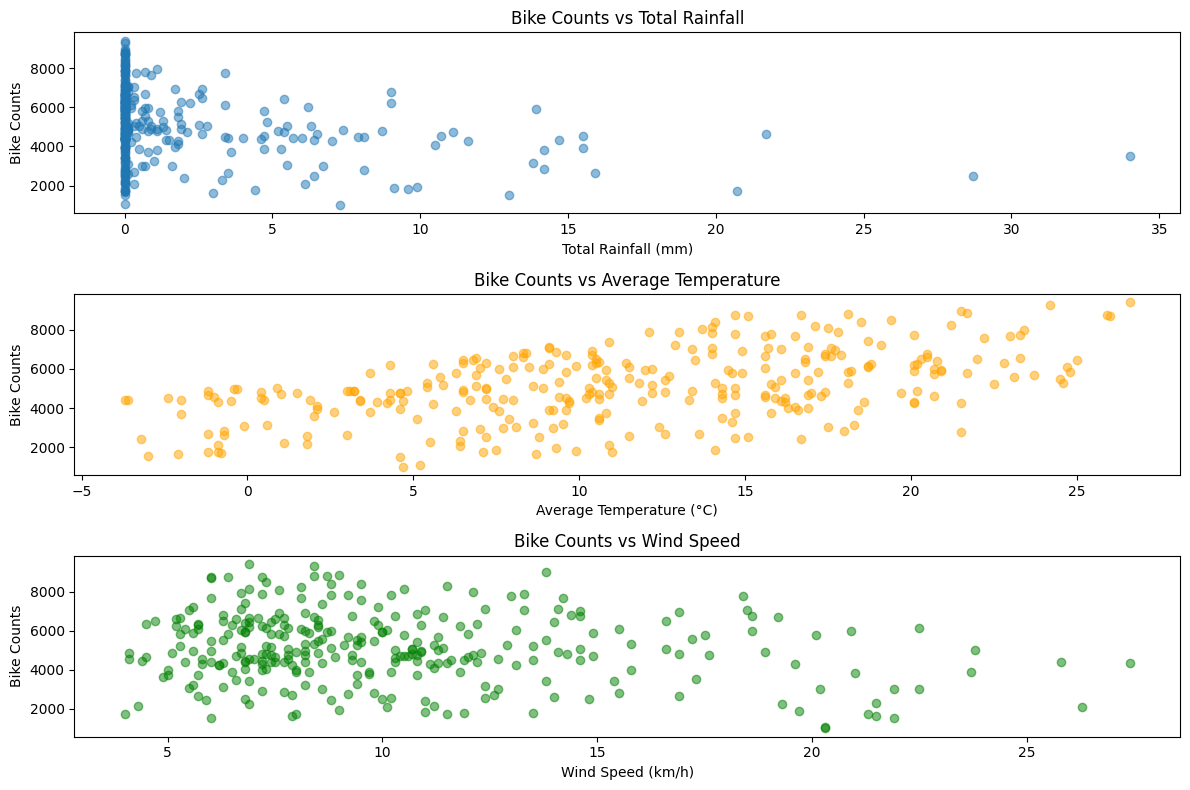

In [46]:
# plot bike counts vs weather parameters
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.scatter(tue_total_rain, tue_bike_counts, alpha=0.5)
plt.title('Bike Counts vs Total Rainfall')
plt.xlabel('Total Rainfall (mm)')
plt.ylabel('Bike Counts')
plt.subplot(3, 1, 2)
plt.scatter(tue_avg_temp, tue_bike_counts, alpha=0.5,
            color='orange')
plt.title('Bike Counts vs Average Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Bike Counts')
plt.subplot(3, 1, 3)
plt.scatter(tue_wind_speed, tue_bike_counts, alpha=0.5,
            color='green')
plt.title('Bike Counts vs Wind Speed')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Bike Counts')
plt.tight_layout()
plt.show()


The second subplot suggests a strong correlation with temperature. The other plots seem mostly useless.

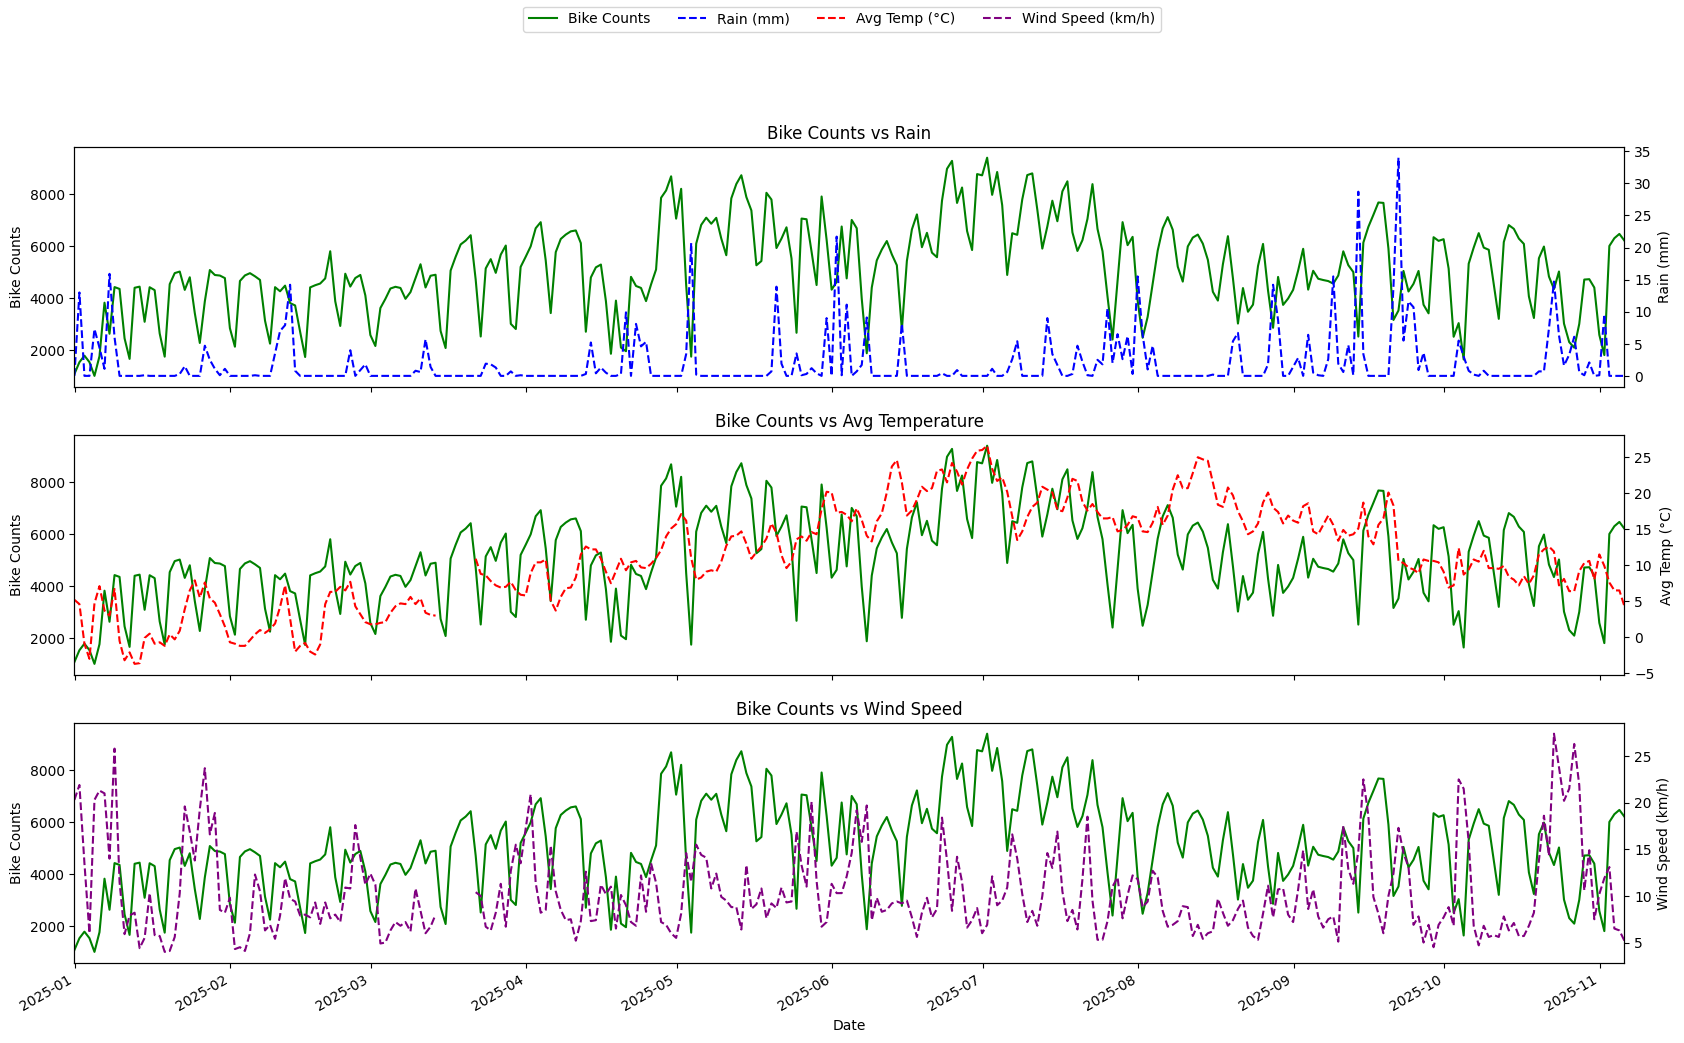

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Rain
ax_rain = axes[0]
ax_rain.plot(dates, tue_bike_counts, color='green', label='Bike Counts')
ax_rain.set_ylabel('Bike Counts')
ax_rain2 = ax_rain.twinx()
ax_rain2.plot(dates, tue_total_rain, color='blue', linestyle='--', label='Rain (mm)')
ax_rain2.set_ylabel('Rain (mm)')
ax_rain.set_title('Bike Counts vs Rain')

# Temperature
ax_temp = axes[1]
ax_temp.plot(dates, tue_bike_counts, color='green')
ax_temp.set_ylabel('Bike Counts')
ax_temp2 = ax_temp.twinx()
ax_temp2.plot(dates, tue_avg_temp, color='red', linestyle='--', label='Avg Temp (°C)')
ax_temp2.set_ylabel('Avg Temp (°C)')
ax_temp.set_title('Bike Counts vs Avg Temperature')

# Wind
ax_wind = axes[2]
ax_wind.plot(dates, tue_bike_counts, color='green')
ax_wind.set_ylabel('Bike Counts')
ax_wind2 = ax_wind.twinx()
ax_wind2.plot(dates, tue_wind_speed, color='purple', linestyle='--', label='Wind Speed (km/h)')
ax_wind2.set_ylabel('Wind Speed (km/h)')
ax_wind.set_title('Bike Counts vs Wind Speed')
ax_wind.set_xlabel('Date')

for a in axes:
    a.set_xlim(dates.iloc[0], dates.iloc[-1])

fig.autofmt_xdate()
fig.legend(
    [ax_rain.lines[0], ax_rain2.lines[0], ax_temp2.lines[0], ax_wind2.lines[0]],
    ['Bike Counts', 'Rain (mm)', 'Avg Temp (°C)', 'Wind Speed (km/h)'],
    loc='upper center', ncol=4
)

plt.show()


Wind speed seems irrelevant. Temperature seems to influence the overall count, rainfall seems to have a direct negative influene.

In [48]:
# calculate correlations
corr_rain = tue_bike_counts.corr(tue_total_rain)
corr_temp = tue_bike_counts.corr(tue_avg_temp)
corr_wind = tue_bike_counts.corr(tue_wind_speed)

print(f'Correlation between Bike Counts and Rain: {corr_rain:.2f}')
print(f'Correlation between Bike Counts and Average Temperature: {corr_temp:.2f}')
print(f'Correlation between Bike Counts and Wind Speed: {corr_wind:.2f}')


Correlation between Bike Counts and Rain: -0.29
Correlation between Bike Counts and Average Temperature: 0.51
Correlation between Bike Counts and Wind Speed: -0.19


Mostly what I expected. I guess we could get a stronger result for rain if we can eliminate the temperature influence. 

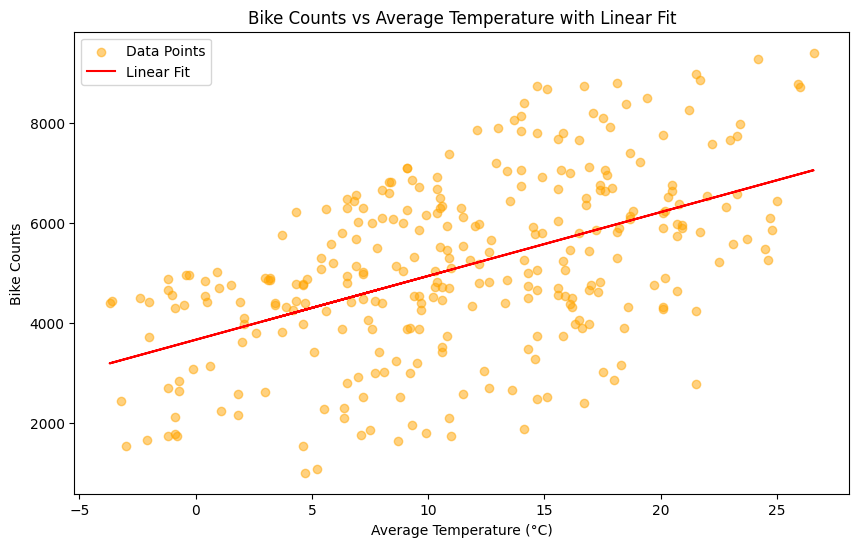

In [49]:
# fit linear model to influence of temperature 
import numpy as np
from sklearn.linear_model import LinearRegression # (pip install scikit-learn)

X_temp = tue_avg_temp.values.reshape(-1, 1)
# interpolate missing values (probably not the best way here, but simple)
X_temp = np.nan_to_num(X_temp, nan=np.nanmean(X_temp))

y_counts = tue_bike_counts.values
model_temp = LinearRegression()
model_temp.fit(X_temp, y_counts)
y_pred_temp = model_temp.predict(X_temp)
plt.figure(figsize=(10, 6))
plt.scatter(tue_avg_temp, tue_bike_counts, alpha=0.5, label='Data Points', color='orange')
plt.plot(tue_avg_temp, y_pred_temp, color='red', label='Linear Fit')
plt.title('Bike Counts vs Average Temperature with Linear Fit')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Bike Counts')
plt.legend()
plt.show() 


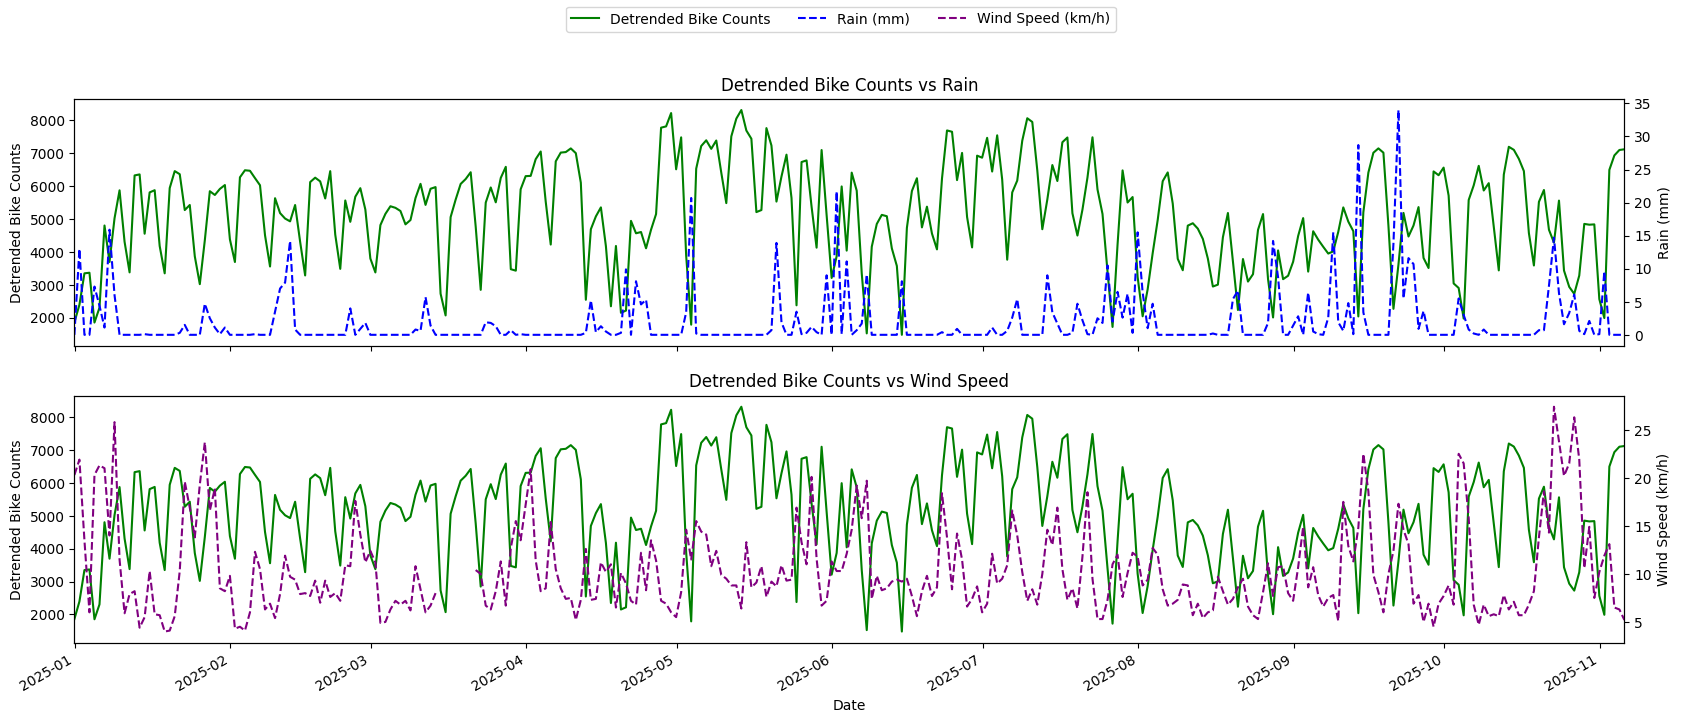

In [50]:
# eliminate temperature influence from bike counts
tue_bike_counts_detrended = tue_bike_counts - y_pred_temp + np.mean(y_pred_temp)

# plot detrended bike counts with rain and wind over time
fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

# Rain
ax_rain = axes[0]
ax_rain.plot(dates, tue_bike_counts_detrended, color='green', label='Detrended Bike Counts')
ax_rain.set_ylabel('Detrended Bike Counts')
ax_rain2 = ax_rain.twinx()
ax_rain2.plot(dates, tue_total_rain, color='blue', linestyle='--', label='Rain (mm)')
ax_rain2.set_ylabel('Rain (mm)')
ax_rain.set_title('Detrended Bike Counts vs Rain')

# Wind
ax_wind = axes[1]
ax_wind.plot(dates, tue_bike_counts_detrended, color='green', label='Detrended Bike Counts')
ax_wind.set_ylabel('Detrended Bike Counts')
ax_wind2 = ax_wind.twinx()
ax_wind2.plot(dates, tue_wind_speed, color='purple', linestyle='--', label='Wind Speed (km/h)')
ax_wind2.set_ylabel('Wind Speed (km/h)')
ax_wind.set_title('Detrended Bike Counts vs Wind Speed')
ax_wind.set_xlabel('Date')  

for a in axes:
    a.set_xlim(dates.iloc[0], dates.iloc[-1])  
fig.autofmt_xdate()
fig.legend(
    [ax_rain.lines[0], ax_rain2.lines[0], ax_wind2.lines[0]],
    ['Detrended Bike Counts', 'Rain (mm)', 'Wind Speed (km/h)'],
    loc='upper center', ncol=3
)
plt.show()


In [51]:
# Calculate correlations for detrended bike counts
corr_rain_detrended = tue_bike_counts_detrended.corr(tue_total_rain)
corr_wind_detrended = tue_bike_counts_detrended.corr(tue_wind_speed)

print(f'Correlation between Detrended Bike Counts and Rain: {corr_rain_detrended:.2f}')
print(f'Correlation between Detrended Bike Counts and Wind Speed: {corr_wind_detrended:.2f}')


Correlation between Detrended Bike Counts and Rain: -0.38
Correlation between Detrended Bike Counts and Wind Speed: -0.22


Nice I guess? I don't know if that's a valid method though...

Doesn't work so well for 2024 :(